# When can we trust a sector ETF's factor exposures?

Fama–French factors, SVD geometry and robust attribution.

## Findings
Across ten original broad iShares funds, fixed ridge reduces reconstruction MSE by **1.93%** relative to OLS. The paired difference is **-0.177 pp²**, with a 95% block interval **[-0.398, 0.028]**. The interval spans zero. Ridge smooths exposures, but the evidence does not establish an improvement. PCR rank four performs worse on the point estimate.

The contribution is a disciplined comparison of attribution methods, not a trading strategy.

## Context and methods
The response is monthly simple ETF return less RF; the regressors are FF5 plus momentum in consistent decimal units. Full-sample fits describe history. Rolling estimates use only preceding observations, then reconstruct the next return with its **realized factors**. The primary window is 60 months, ridge lambda is 0.1 in mean-loss units, and PCR retains four singular directions.

### Key assumptions
Yahoo adjusted close is a total-return proxy. Current-vintage factors and evolving fund benchmarks prevent a point-in-time holdings or deployment interpretation. The ten funds are selected survivors. [Protocol](research/PROTOCOL.md) records the design and bounded sensitivities.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/models.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
RESULTS = ROOT / 'research/results'
FIGURES = ROOT / 'research/figures'


## Data
The common sample has 235 months, January 2007–July 2026. December 2006 supplies the first return denominator. Raw downloads stay local; source URLs, retrieval timestamps and checksums are public.

In [2]:
from research.data import load_panel
x, y, audit = load_panel()
display(pd.Series({k: audit[k] for k in ['etfs','price_rows_per_etf','monthly_observations','first_month','last_month','missing_prices','missing_factors','fills']}).to_frame('Validated panel'))

,Validated panel
etfs,10
price_rows_per_etf,4945
monthly_observations,235
first_month,2007-01
last_month,2026-07
missing_prices,0
missing_factors,0
fills,0


## Economic exposures
These are economic regression coefficients, not holdings weights. Market exposure differs across sectors; the remaining factors refine rather than replace that common equity risk.

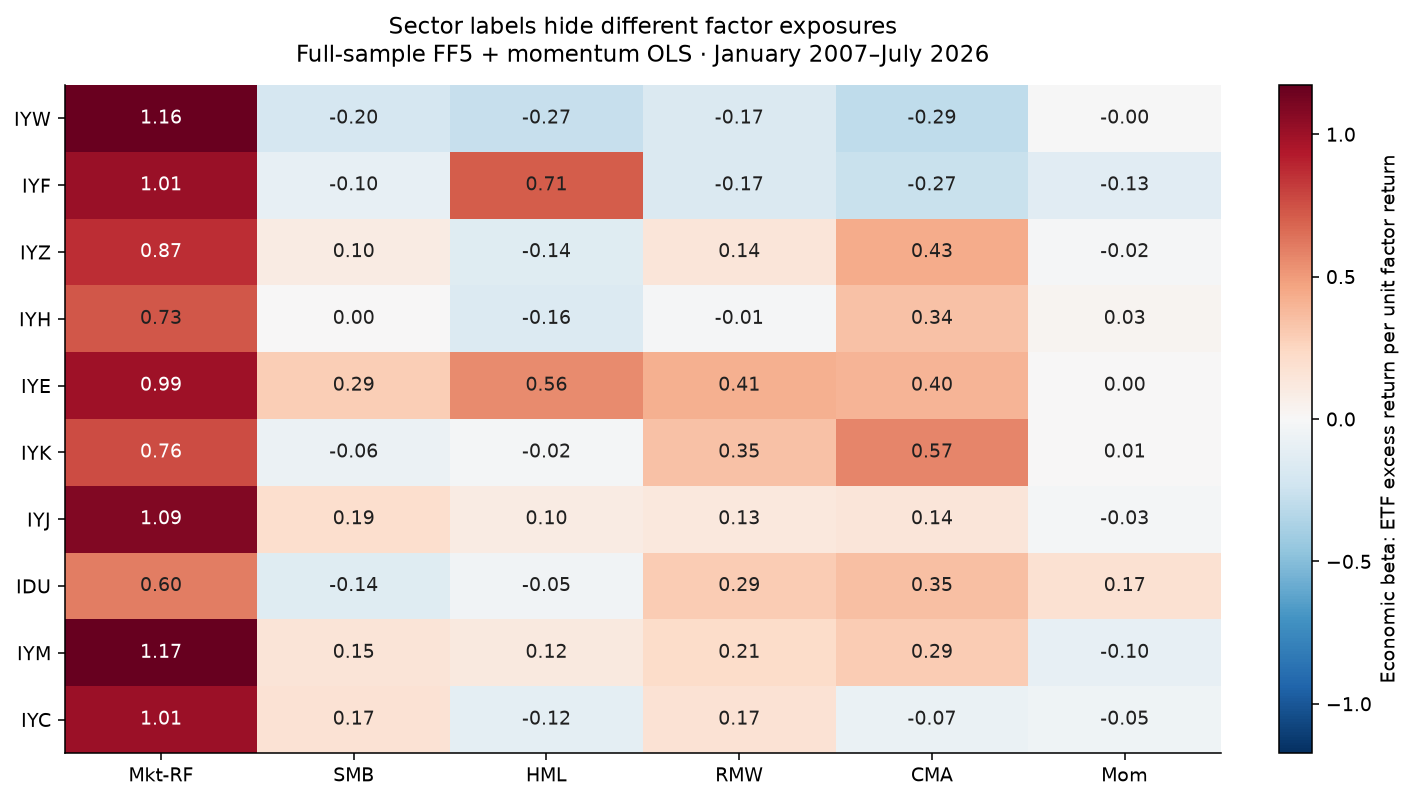

,ticker,r_squared,residual_vol_annual_pct
0,IYW,0.861,7.544
1,IYF,0.891,6.831
2,IYZ,0.587,11.382
3,IYH,0.587,9.290
4,IYE,0.539,17.769
5,IYK,0.715,7.459
6,IYJ,0.909,5.717
7,IDU,0.349,11.680
8,IYM,0.743,11.575
9,IYC,0.885,5.986


In [3]:
display(Image(filename=str(FIGURES / 'factor_map.png')))
display(pd.read_csv(RESULTS / 'exposures.csv')[['ticker','r_squared','residual_vol_annual_pct']].round(3))

## SVD diagnoses the problem before changing the estimator
The median rolling condition number is **2.94**, ranging from **2.42 to 3.74**. These actual factor designs are not numerically near-singular. In the final training window, ridge attenuates each singular direction continuously; PCR deletes two directions. Small factor variance does not imply little information about a particular ETF.

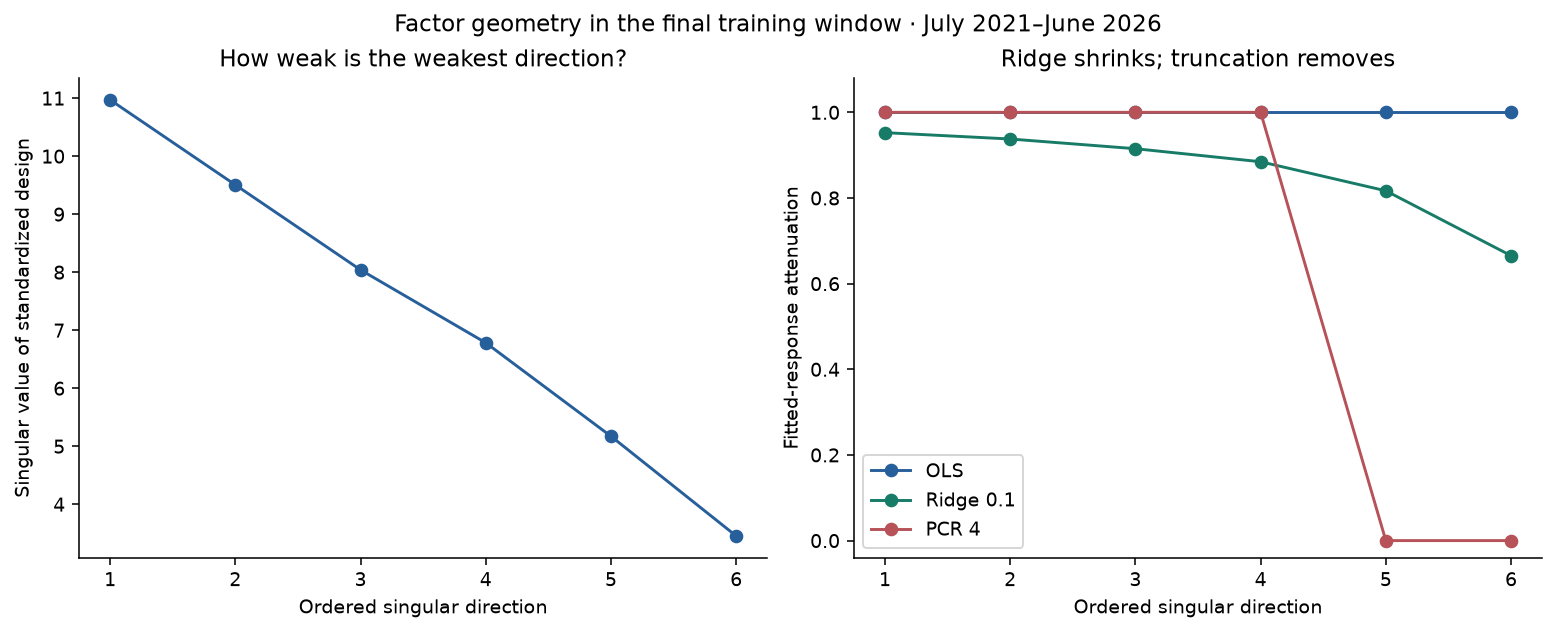

In [4]:
display(Image(filename=str(FIGURES / 'singular_geometry.png')))

## Recompute the primary comparison
The next cell fits every primary model again from the pinned inputs. The supplied factors from the target month make this conditional reconstruction, not a before-month prediction.

In [5]:
from research.run_study import rolling_reconstruction, comparison, summarize
paths = rolling_reconstruction(x, y)
head = comparison(paths)
recorded = json.loads((RESULTS / 'headline.json').read_text())
for key in ['estimate','lower95','upper95','relative_mse_reduction_pct']:
    assert np.isclose(head[key], recorded[key], rtol=1e-10, atol=1e-12)
display(summarize(paths).round(4))
display(pd.Series({k: head[k] for k in ['estimate','lower95','upper95','n']}).to_frame('Paired MSE difference (pp²)'))

,model,months,etfs,rmse_pct_monthly,mse_pp2,rms_beta_monthly_change,mean_effective_df_including_intercept
0,Market,175,10,3.3741,11.3843,0.0090,2.000
1,FF5,175,10,3.0256,9.1540,0.0407,6.000
2,OLS,175,10,3.0288,9.1736,0.0434,7.000
3,Ridge 0.1,175,10,2.9994,8.9964,0.0347,6.153
4,PCR 4,175,10,3.2979,10.8761,0.0854,5.000


,Paired MSE difference (pp²)
estimate,-0.177198
lower95,-0.397819
upper95,0.028245
n,175.000000


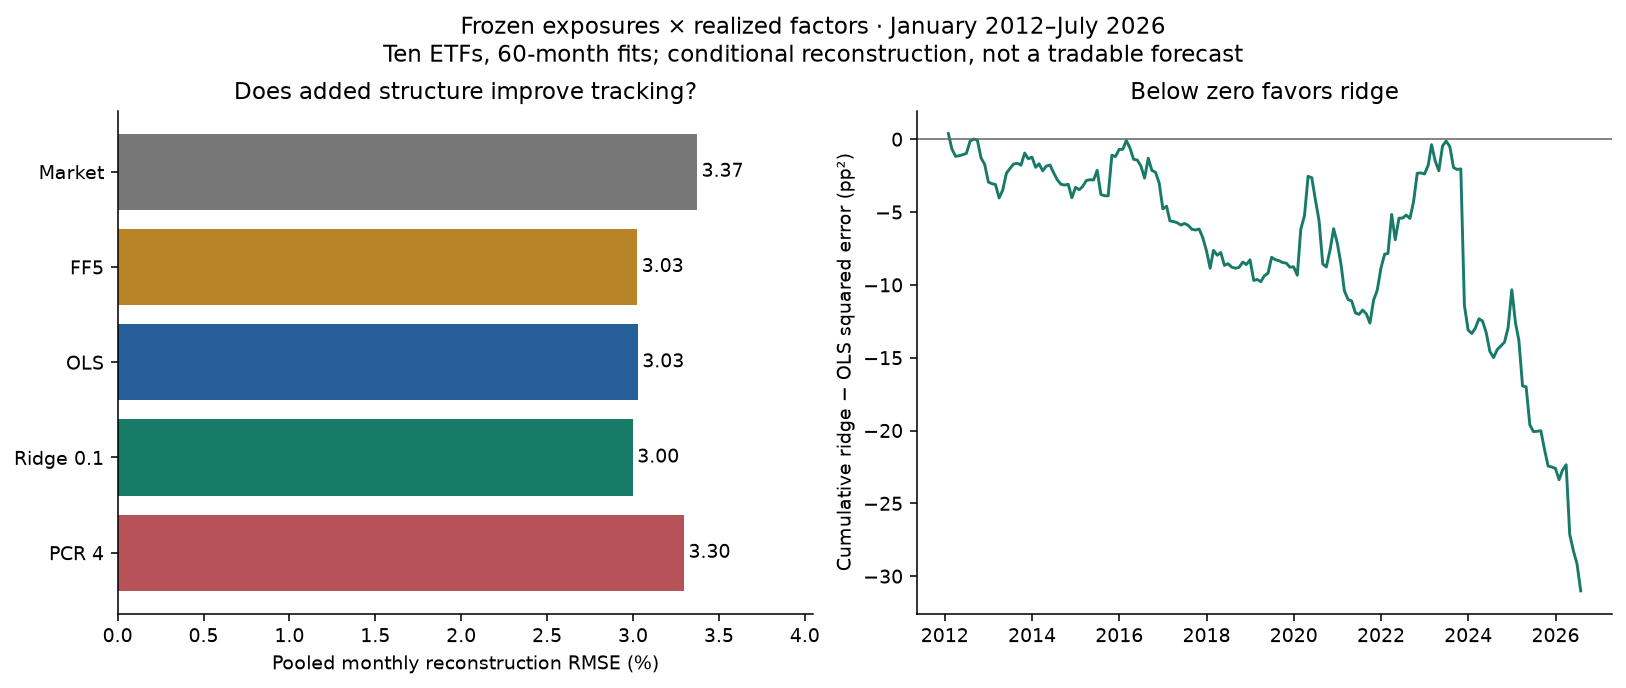

In [6]:
display(Image(filename=str(FIGURES / 'reconstruction.png')))

## Coefficient stability and reconstruction accuracy are different
Ridge lowers the RMS change in the six economic betas. PCR's changing truncated subspace produces more unstable raw exposures in this sample. Neither smoothness nor explained factor variance is itself evidence of better attribution.

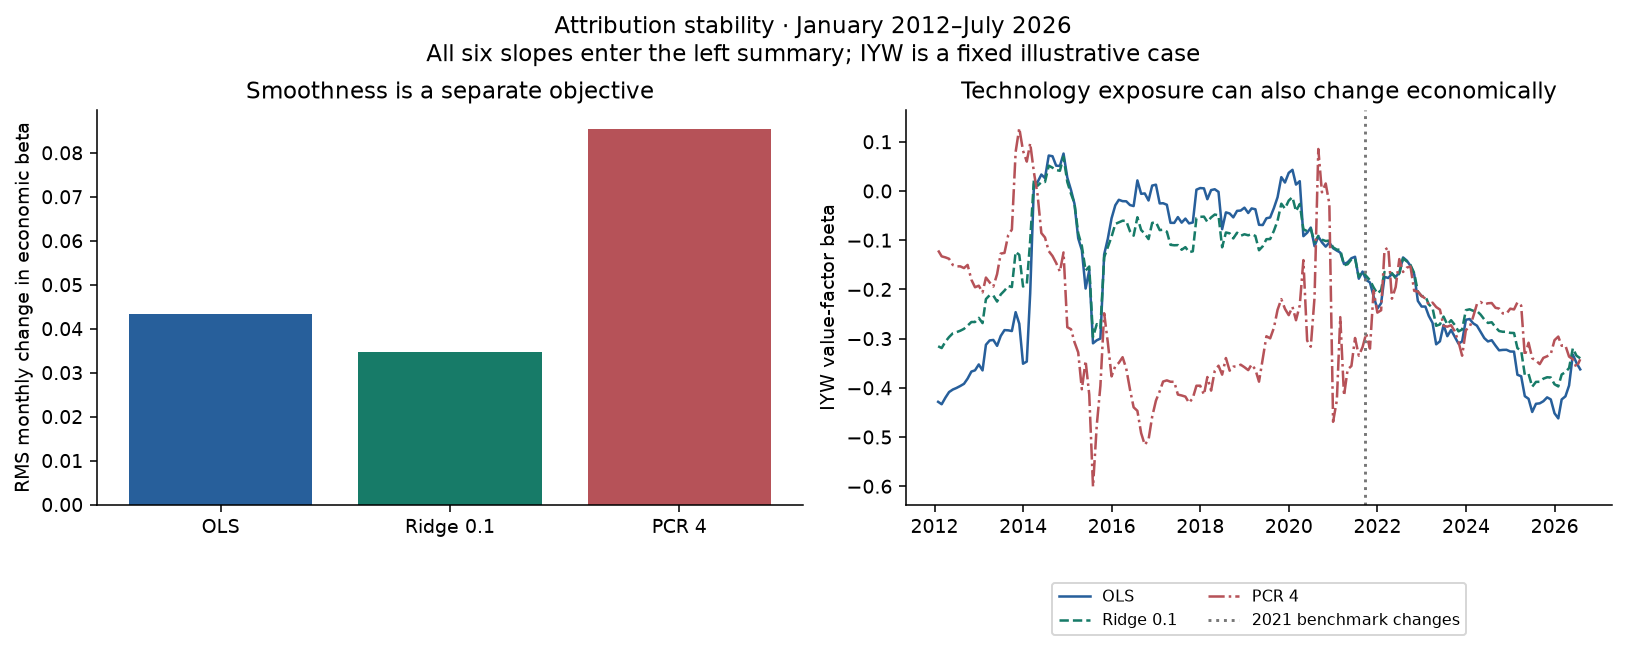

In [7]:
display(Image(filename=str(FIGURES / 'stability.png')))

## Residual means and uncertainty
The intervals are six-lag HAC, pointwise and normal-approximation. No intercept survives Holm adjustment across the ten ETFs at 5%. This is not proof that every alpha is zero; precision, omitted factors and changing betas matter.

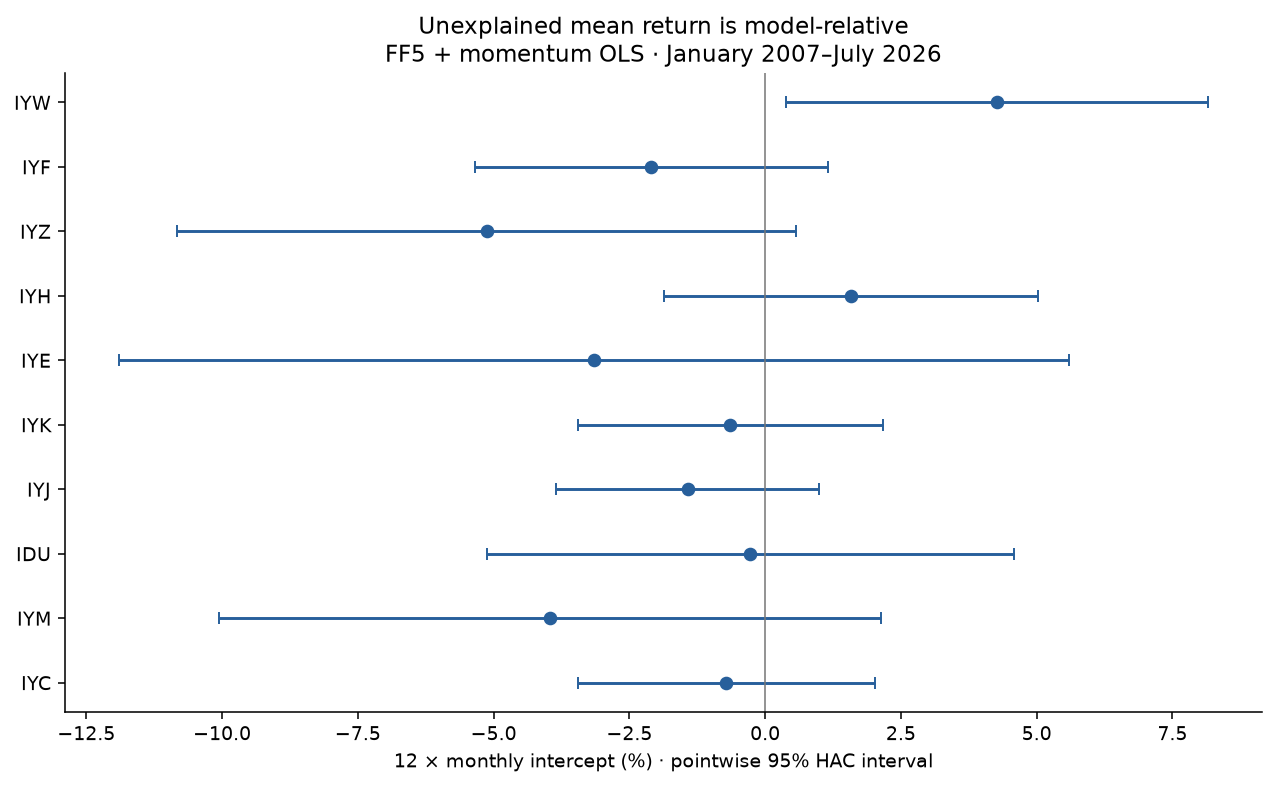

,ticker,alpha_arithmetic_annual_pct,lower95_arithmetic_annual_pct,upper95_arithmetic_annual_pct,holm_p_value
0,IYW,4.267,0.382,8.153,0.314
1,IYF,-2.094,-5.348,1.160,1.000
2,IYZ,-5.130,-10.825,0.565,0.697
3,IYH,1.579,-1.863,5.021,1.000
4,IYE,-3.152,-11.897,5.593,1.000
5,IYK,-0.642,-3.448,2.164,1.000
6,IYJ,-1.425,-3.851,1.000,1.000
7,IDU,-0.270,-5.116,4.577,1.000
8,IYM,-3.956,-10.054,2.142,1.000
9,IYC,-0.714,-3.446,2.018,1.000


In [8]:
display(Image(filename=str(FIGURES / 'alpha_intervals.png')))
display(pd.read_csv(RESULTS / 'alpha.csv')[['ticker','alpha_arithmetic_annual_pct','lower95_arithmetic_annual_pct','upper95_arithmetic_annual_pct','holm_p_value']].round(3))

## Sensitivities without choosing a winner
Keep the stronger and weaker penalties, all retained ranks, and windows on common dates. The favorable 36-month result is supporting evidence; it does not rewrite the prespecified primary result.

In [9]:
display(pd.read_csv(RESULTS / 'estimator_sensitivity.csv').round(4))
windows = pd.read_csv(RESULTS / 'window_sensitivity.csv')
display(windows[windows.scope.eq('common dates')][['window','estimate','lower95','upper95','relative_mse_reduction_pct']].round(4))

,model,months,etfs,rmse_pct_monthly,mse_pp2,rms_beta_monthly_change,mean_effective_df_including_intercept
0,Market,175,10,3.3741,11.3843,0.0090,2.0000
1,FF5,175,10,3.0256,9.1540,0.0407,6.0000
2,OLS,175,10,3.0288,9.1736,0.0434,7.0000
3,Ridge 0.1,175,10,2.9994,8.9964,0.0347,6.1530
4,PCR 4,175,10,3.2979,10.8761,0.0854,5.0000
5,Ridge 0.01,175,10,3.0193,9.1162,0.0421,6.8963
6,Ridge 1,175,10,3.5420,12.5455,0.0192,3.6272
7,PCR 3,175,10,3.8744,15.0113,0.0569,4.0000
8,PCR 5,175,10,3.0746,9.4533,0.0851,6.0000


,window,estimate,lower95,upper95,relative_mse_reduction_pct
1,60,-0.2281,-0.5568,0.0910,2.0916
3,36,-0.4810,-0.9291,-0.0912,4.1979
5,120,-0.1658,-0.4580,0.1262,1.5598


## Takeaways
Use SVD to understand identification, preserve economic units, and test whether regularization earns its bias. In this vintage, fixed ridge smooths exposures and has a modest, uncertain reconstruction advantage; aggressive shrinkage or truncation can remove useful information. More reliable attribution would require independent price reconciliation, dated holdings and a genuinely later evaluation period.

Explore the [five chapters](README.md#explore-the-research), [sources](research/SOURCES.md), [full evidence](docs/03-results.md), and [next experiments](research/RESEARCH_AGENDA.md).